# EDA - анализ данных по химическим соединениям

Данные от химиков: 1000 соединений, протестированных на активность против вируса гриппа.

Целевые переменные:
- **IC50** - чем меньше, тем активнее соединение против вируса
- **CC50** - чем больше, тем менее токсично для клеток  
- **SI = CC50 / IC50** - индекс селективности, хотим чтобы был как можно выше

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_excel('/content/Данные_для_курсовои_Классическое_МО (1).xlsx')
print(df)

      Unnamed: 0    IC50, mM    CC50, mM         SI  MaxAbsEStateIndex  \
0              0    6.239374  175.482382  28.125000           5.094096   
1              1    0.771831    5.402819   7.000000           3.961417   
2              2  223.808778  161.142320   0.720000           2.627117   
3              3    1.705624  107.855654  63.235294           5.097360   
4              4  107.131532  139.270991   1.300000           5.150510   
...          ...         ...         ...        ...                ...   
996          996   31.000104   34.999650   1.129017          12.934891   
997          997   31.999934   33.999415   1.062484          13.635345   
998          998   30.999883   33.999458   1.096761          13.991690   
999          999   31.998959   32.999644   1.031272          13.830180   
1000        1000   99.999531   99.999531   1.000000          13.380863   

      MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex       qed        SPS  \
0           5.094096           

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
"IC50, mM",0
"CC50, mM",0
SI,0
MaxAbsEStateIndex,0
...,...
fr_thiazole,0
fr_thiocyan,0
fr_thiophene,0
fr_unbrch_alkane,0


Пропусков нет, все данные числовые. Посмотрим на целевые переменные.

In [ ]:
targets = ['IC50, mM', 'CC50, mM', 'SI']
df[targets].describe().round(2)

,"IC50, mM","CC50, mM",SI
count,1001.00,1001.00,1001.00
mean,222.81,589.11,72.51
std,402.17,642.87,684.48
min,0.00,0.70,0.01
25%,12.52,100.00,1.43
50%,46.59,411.04,3.85
75%,224.98,894.09,16.57
max,4128.53,4538.98,15620.60


Разброс огромный — у IC50 max в тысячи раз больше min. Подозреваю сильную скошенность, надо проверить гистограммы.

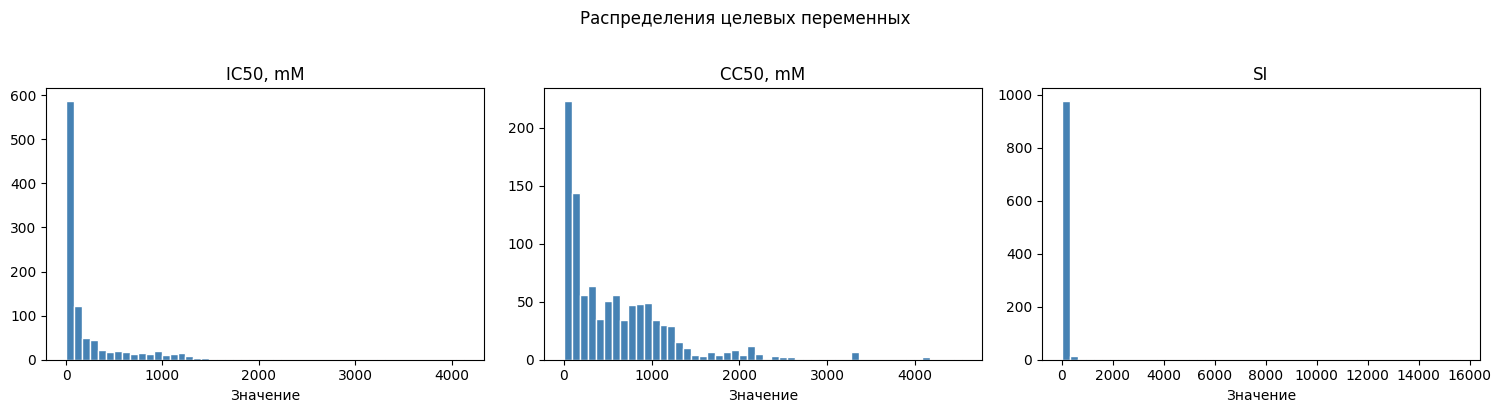

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(targets):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Значение')
plt.suptitle('Распределения целевых переменных', y=1.02)
plt.tight_layout()
plt.show()

Все значения сконцентрированы справа. Большинство значений маленькие, но есть длинный хвост. Необходимо использовать логарифм, чтобы данные были равномерными и не зацикливались при регрессии.

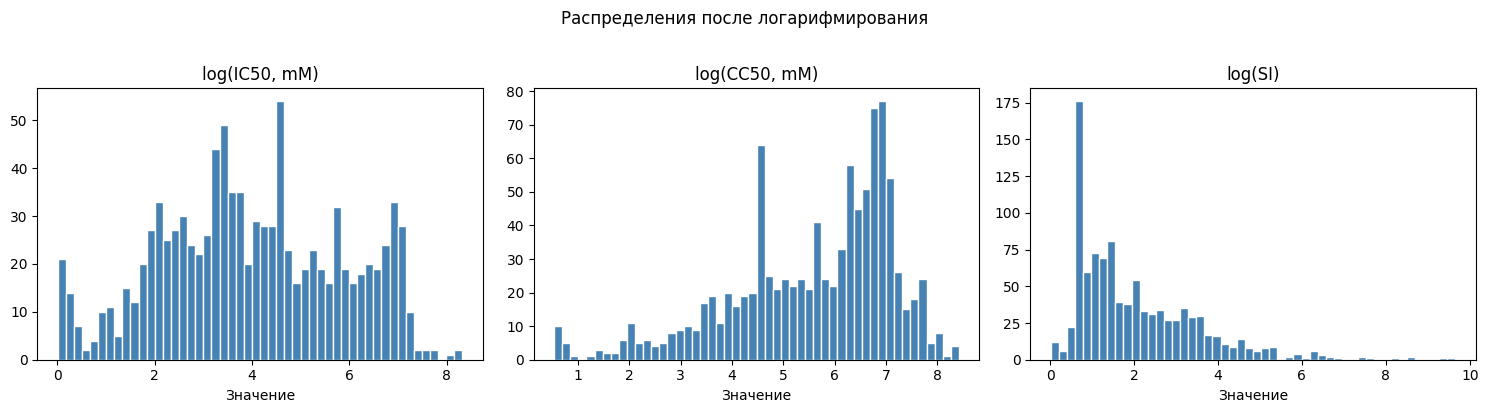

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(targets):
    axes[i].hist(np.log1p(df[col]), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'log({col})')
    axes[i].set_xlabel('Значение')
plt.suptitle('Распределения после логарифмирования', y=1.02)
plt.tight_layout()
plt.show()

Логарифм убирает эту скошенность и приближает распределение к нормальному, что улучшает работу линейных моделей

## Выбросы

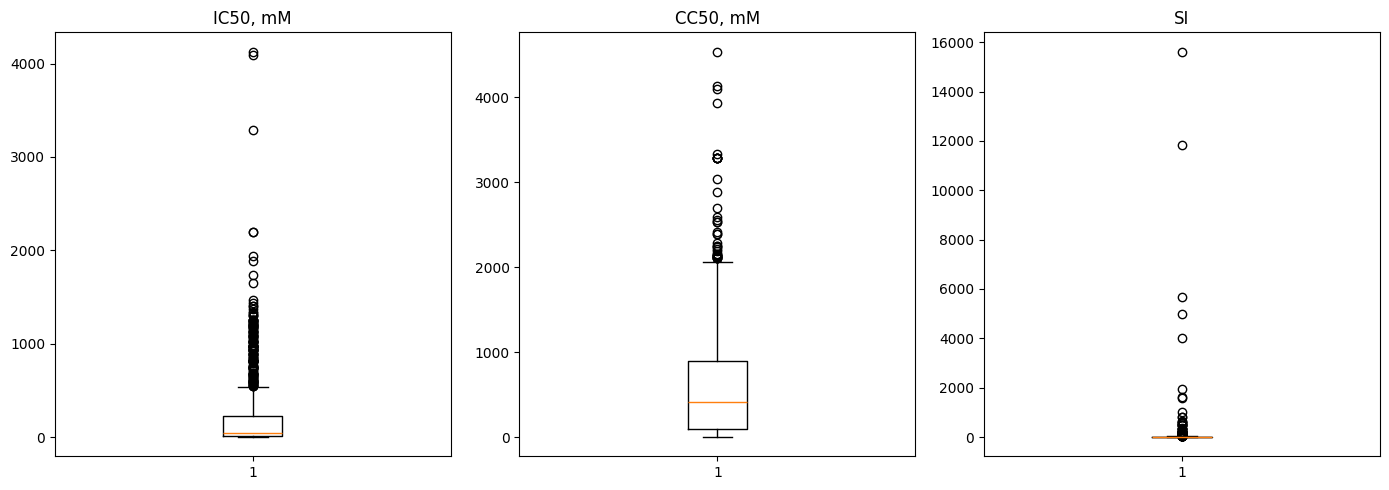

IC50, mM: 147 выбросов (14.7%)
CC50, mM: 39 выбросов (3.9%)
SI: 125 выбросов (12.5%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(targets):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# сколько выбросов по IQR
for col in targets:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {n} выбросов ({n/len(df)*100:.1f}%)')

Выбросов много, но удалять не буду — в химии экстремальные значения часто самые интересные (очень активные или очень безопасные соединения). Лучше использовать методы, устойчивые к выбросам.

## Проверяем формулу SI

In [ ]:
# в задании написано что SI = CC50/IC50, проверю
df['SI_check'] = df['CC50, mM'] / df['IC50, mM']
diff = (df['SI'] - df['SI_check']).abs().max()
print(f'Максимальное отклонение SI от CC50/IC50: {diff:.6f}')
df.drop('SI_check', axis=1, inplace=True)

Максимальное отклонение SI от CC50/IC50: 0.000000


При построении моделей для SI нельзя использовать IC50 и CC50 как признаки — это была бы утечка данных.

## Признаки — посмотрим что есть

In [ ]:
feature_cols = [c for c in df.columns if c not in targets]
print(f'Признаков: {len(feature_cols)}')
print(feature_cols[:10], '...')

Признаков: 211
['Unnamed: 0', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt'] ...


In [ ]:
# дисперсия признаков — нет ли константных
stds = df[feature_cols].std()
print('Признаков с нулевой дисперсией:', (stds == 0).sum())
print('Признаков с очень маленькой дисперсией (<0.001):', (stds < 0.001).sum())

Признаков с нулевой дисперсией: 18
Признаков с очень маленькой дисперсией (<0.001): 18


Обнаружено 18 признаков с нулевой дисперсией — они постоянны для всех соединений и не несут информации. Перед обучением моделей эти признаки нужно удалить.

In [ ]:
# Удаляем постоянные признаки и лишний индексный столбец
cols_to_drop = list(stds[stds == 0].index) + ['Unnamed: 0']
df = df.drop(columns=cols_to_drop, errors='ignore')
feature_cols = [c for c in df.columns if c not in targets]
print(f'Признаков после очистки: {len(feature_cols)}')

Признаков после очистки: 192


## Корреляция признаков с целевыми переменными

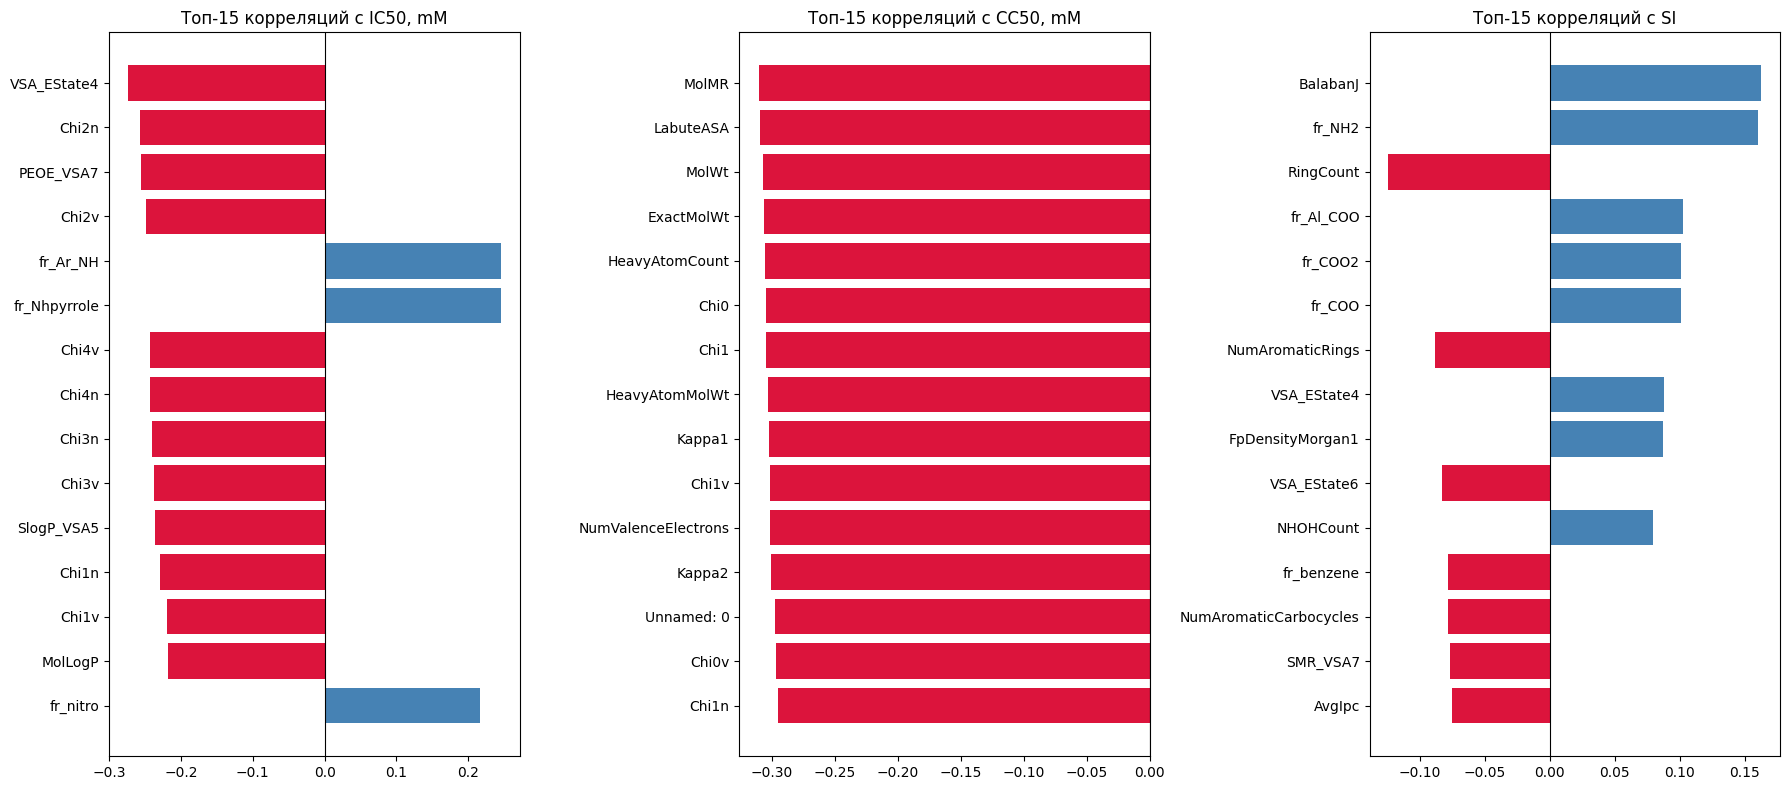

In [ ]:
corr = df.corr(numeric_only=True)[targets].drop(targets)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for i, col in enumerate(targets):
    top = corr[col].abs().sort_values(ascending=False).head(15)
    colors = ['crimson' if corr[col][f] < 0 else 'steelblue' for f in top.index]
    axes[i].barh(top.index[::-1], corr[col][top.index[::-1]], color=colors[::-1])
    axes[i].axvline(0, color='black', lw=0.8)
    axes[i].set_title(f'Топ-15 корреляций с {col}')
plt.tight_layout()
plt.show()

Корреляция между признаками и IC50, CC50 и SI есть.

Для IC50 и CC50 наблюдаются в основном отрицательные корреляции с большинством показателей (особенно в центральных топ-списках), а для SI есть как положительные, так и отрицательные связи в зависимости от признака.

То есть зависимость между признаками и целевыми значениями действительно присутствует, но она разная по направлению и силе.

In [ ]:
corr = df.corr(numeric_only=True)[targets].drop(targets)
corr['IC50, mM'].abs().sort_values(ascending=False).head(3)

,"IC50, mM"
VSA_EState4,0.274203
Chi2n,0.257058
PEOE_VSA7,0.255988


Наибольшую корреляцию с IC50 показывают признаки VSA_EState4 (0.27), Chi2n (0.26) и PEOE_VSA7 (0.26). Корреляции невысокие, что говорит о нелинейной зависимости между признаками и целевой переменной - линейные модели могут справиться хуже, чем ансамблевые.

## Мультиколлинеарность

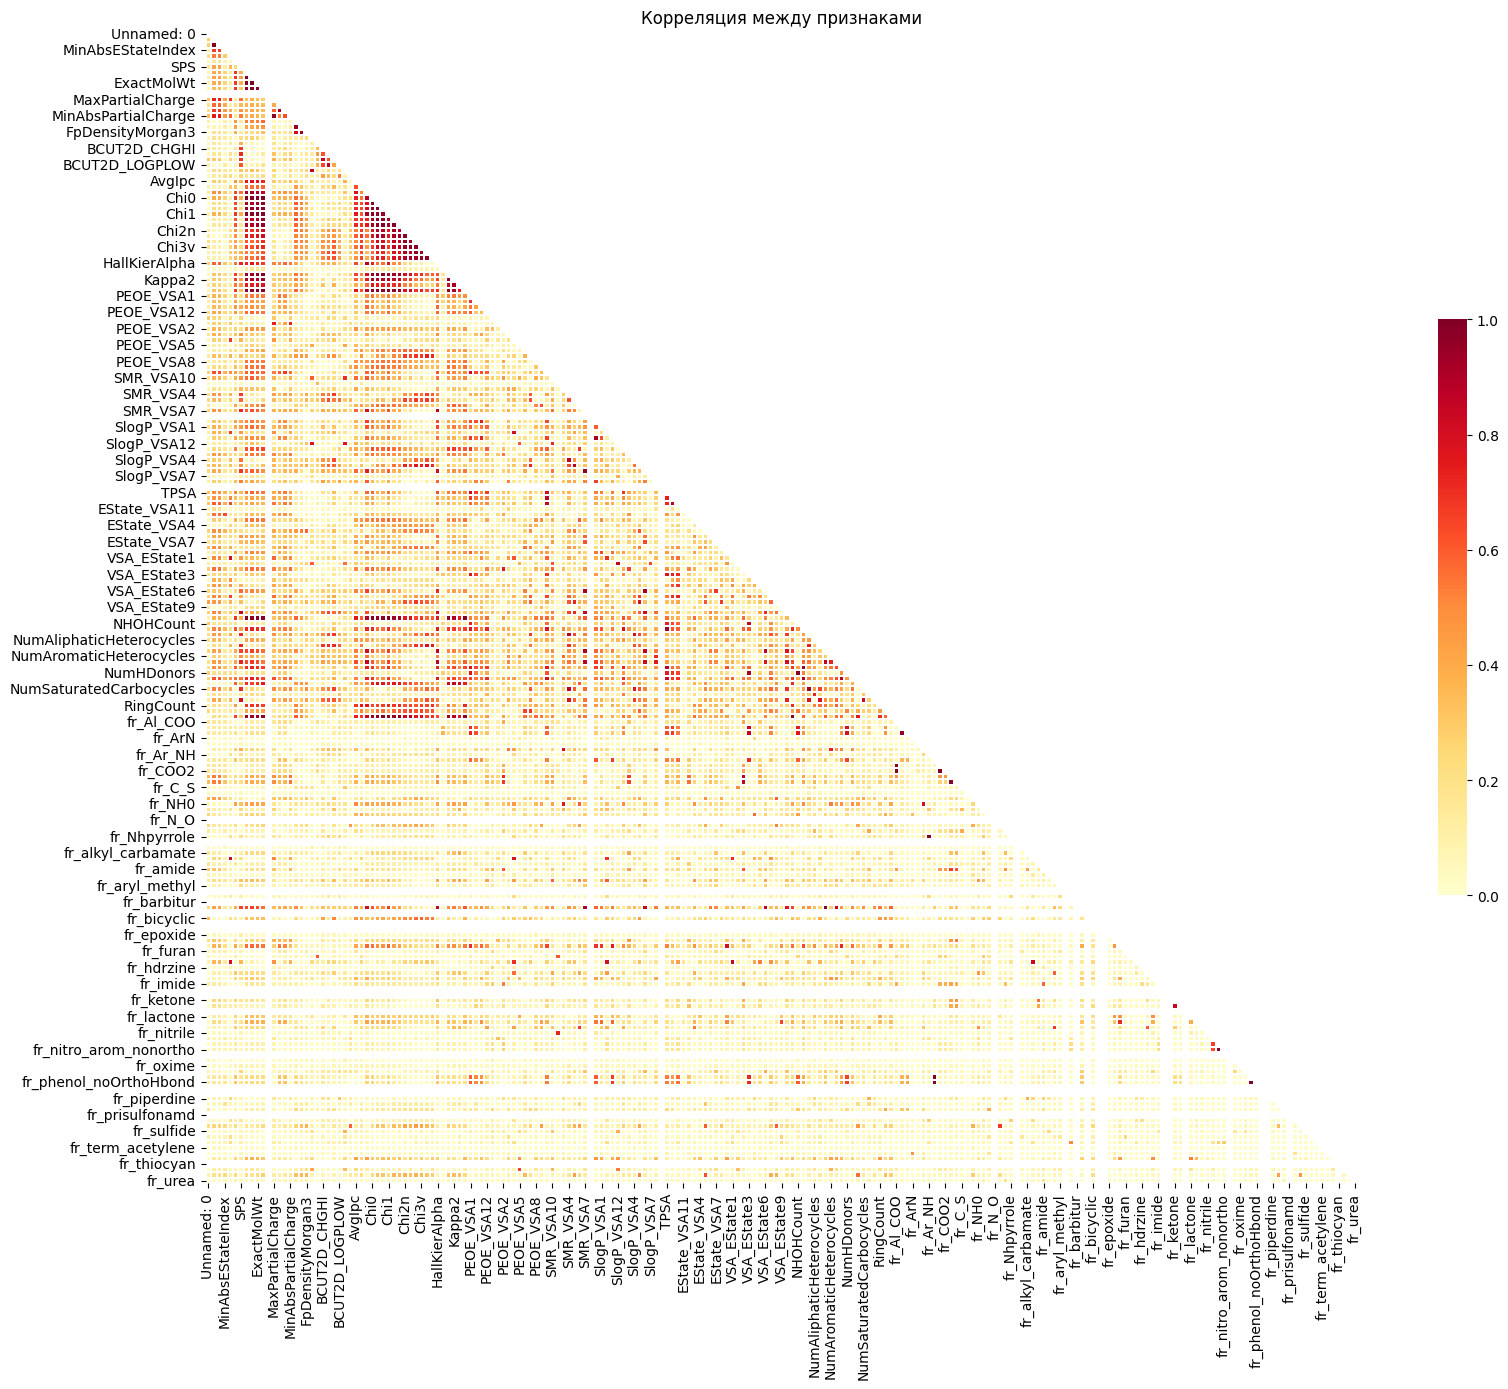

In [ ]:
feat_corr = df[feature_cols].corr().abs()
mask = np.triu(np.ones_like(feat_corr, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(feat_corr, mask=mask, cmap='YlOrRd', vmin=0, vmax=1,
            square=True, linewidths=0.1, cbar_kws={'shrink': 0.5})
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

In [ ]:
# сколько сильно коррелированных пар
high = []
cols = feat_corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if feat_corr.iloc[i, j] > 0.95:
            high.append((cols[i], cols[j], round(feat_corr.iloc[i, j], 3)))

print(f'Пар с корреляцией > 0.95: {len(high)}')
for a, b, v in high[:5]:
    print(f'  {a} <-> {b}: {v}')

Пар с корреляцией > 0.95: 91
  MaxAbsEStateIndex <-> MaxEStateIndex: 1.0
  MolWt <-> HeavyAtomMolWt: 0.997
  MolWt <-> ExactMolWt: 1.0
  MolWt <-> NumValenceElectrons: 0.981
  MolWt <-> Chi0: 0.987


Много сильно коррелированных признаков — это нормально, так как признаки описывают похожие структурные свойства. Для работы с такими данными подойдут ансамблевые модели.

## Пороги для классификации

In [ ]:
print('Медианы:')
for col in targets:
    print(f'  {col}: {df[col].median():.4f}')

print(f'\nСоединений с SI > 8: {(df["SI"] > 8).sum()} ({(df["SI"] > 8).mean()*100:.1f}%)')
print(f'Соединений с SI <= 8: {(df["SI"] <= 8).sum()} ({(df["SI"] <= 8).mean()*100:.1f}%)')

Медианы:
  IC50, mM: 46.5852
  CC50, mM: 411.0393
  SI: 3.8462

Соединений с SI > 8: 357 (35.7%)
Соединений с SI <= 8: 644 (64.3%)


Задача SI > 8 имеет дисбаланс классов (35.7% / 64.3%), что потребует использования class_weight='balanced' при обучении моделей классификации.

## Итого по EDA

1. Данные чистые, пропусков нет
2. Целевые переменные сильно скошены, поэтому нужен логарифм перед регрессией
3. SI = CC50/IC50, при моделировании SI исключать IC50 и CC50 из признаков
4. Много мультиколлинеарных признаков, буду использовать ансамблевые методы
5. Выбросы есть, но информативны
6. Медианные пороги дают баланс 50/50, SI > 8 — несбалансированная задача